In [7]:
import tifffile as tiff
import rasterio
from rasterio.features import geometry_mask
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sys
sys.path.append("..")  # Ajouter le dossier parent au chemin
from core2.eva_losses import eva_acc, eva_dice, eva_miou, eva_sensitivity, eva_specificity
from eva_losses import eva_metrics

# Train

## Importer l'image de ground truth (labels)



Dimensions: (1658, 2861)
Nombre de bandes : 1
Projection : EPSG:26910
Min: nan, Max: nan, Moyenne: nan
L'image contient d'autres valeurs : [ 0.  1. nan]
Nombre de pixels par classe :
Classe 0.0: 3484962 pixels
Classe 1.0: 434370 pixels
Classe nan: 824206 pixels
proportion de pixels de la classe 1 : 11.08%


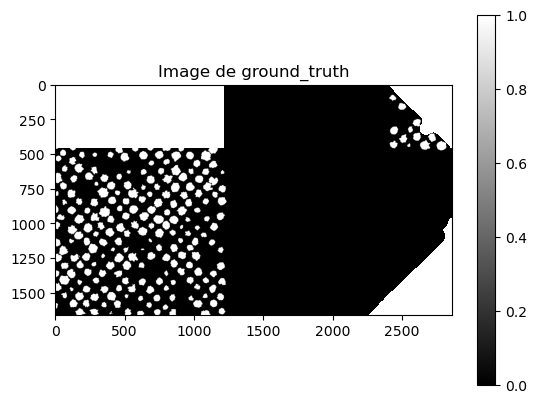

In [11]:
# Ouvrir image de Ground Truth
with rasterio.open(r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_JRW45\Test_exemple\Test_exemple\groundtruth.png") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    print(f"Projection : {src.crs}")
    ground_truth = src.read(1)

#Importer le shapefile de la zone test
import geopandas as gpd
from rasterio.features import geometry_mask
test_areas = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp')

#Conserver seulement les zones de test sur l'image de ground truth
# Créer un masque à partir des zones de test
test_mask = geometry_mask(test_areas.geometry, transform=src.transform, invert=True, out_shape=ground_truth.shape)

# Appliquer le masque à l'image de ground truth
ground_truth = np.where(test_mask, ground_truth, np.nan)

# Statistiques de l’image
print(f"Min: {ground_truth.min()}, Max: {ground_truth.max()}, Moyenne: {ground_truth.mean()}")

# Vérifier qu'il y a seulement des 0 ou des 1 dans l'image
unique_values = np.unique(ground_truth)
if np.array_equal(unique_values, [0, 1]):
    print("L'image contient uniquement des 0 et des 1.")
else:
    print(f"L'image contient d'autres valeurs : {unique_values}")

# Compter le nombre de pixels de chaque classe
unique, counts = np.unique(ground_truth, return_counts=True)
print("Nombre de pixels par classe :")
for value, count in zip(unique, counts):
    print(f"Classe {value}: {count} pixels")

print(f"proportion de pixels de la classe 1 : {counts[1] / (counts[0] + counts[1]) * 100:.2f}%")

# Normaliser entre 0 et 255
#ground_truth_normalized = (ground_truth - ground_truth.min()) / (ground_truth.max() - ground_truth.min()) * 255
#ground_truth_normalized = ground_truth_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
#with rasterio.open("C:/Git/données_pour_metric/données_pour_metric/fichier_avec_0_epoch/prediction_seg_2018_1km_6294_463_fixed.tif", "w", driver="GTiff",
#                   height=ground_truth.shape[0], width=ground_truth.shape[1],
#                   count=1, dtype=ground_truth_normalized.dtype) as dst:
#    dst.write(ground_truth_normalized, 1)


#visualiser l'image de labels
plt.imshow(ground_truth, cmap="gray")
plt.colorbar()
plt.title("Image de ground_truth")
plt.show()

### Importer et visualiser l'image de segmentation (output du modèle)

Dimensions: (1658, 2861)
Nombre de bandes : 1
Projection : None
Min: 0, Max: 1, Moyenne: 0.08601343554115093
L'image contient uniquement des 0 et des 1.
Nombre de pixels par classe :
Classe 0: 4335530 pixels
Classe 1: 408008 pixels
proportion de pixels de la classe 1 : 8.60%


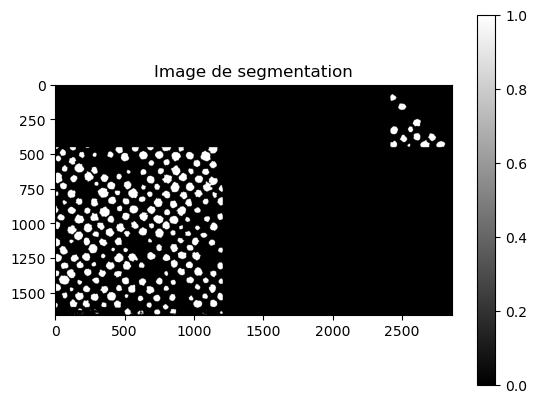

In [13]:
# Ouvrir image de segmentation (output du modèle)
with rasterio.open(r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_JRW45\Test_exemple\Test_exemple\test_image_inference_seg.tif") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    print(f"Projection : {src.crs}")
    segmentation = src.read(1)

#Je voudrais appliquer le même masque que pour l'image de ground truth
# Créer un masque à partir des zones de test
segmentation_nan = np.where(test_mask, segmentation, np.nan)

# Statistiques de l’image
# Filtrer les NaN pour le calcul
#segmentation = segmentation_nan[~np.isnan(segmentation_nan)]

print(f"Min: {segmentation.min()}, Max: {segmentation.max()}, Moyenne: {segmentation.mean()}")

# Vérifier qu'il y a seulement des 0 ou des 1 dans l'image
unique_values = np.unique(segmentation)
if np.array_equal(unique_values, [0, 1]):
    print("L'image contient uniquement des 0 et des 1.")
else:
    print(f"L'image contient d'autres valeurs : {unique_values}")

# Compter le nombre de pixels de chaque classe
unique, counts = np.unique(segmentation, return_counts=True)
print("Nombre de pixels par classe :")
for value, count in zip(unique, counts):
    print(f"Classe {value}: {count} pixels")

print(f"proportion de pixels de la classe 1 : {counts[1] / (counts[0] + counts[1]) * 100:.2f}%")

# Normaliser entre 0 et 255
#segmentation_normalized = (segmentation - segmentation.min()) / (segmentation.max() - segmentation.min()) * 255
#segmentation_normalized = segmentation_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
#with rasterio.open("C:/Git/données_pour_metric/données_pour_metric/fichier_avec_0_epoch/prediction_seg_2018_1km_6294_463_fixed.tif", "w", driver="GTiff",
#                   height=segmentation.shape[0], width=segmentation.shape[1],
#                   count=1, dtype=segmentation_normalized.dtype) as dst:
#    dst.write(segmentation_normalized, 1)


#visualiser l'image de segmentation
plt.imshow(segmentation, cmap="gray")
plt.colorbar()
plt.title("Image de segmentation")
plt.show()


## Calculer les métriques

In [9]:
from sklearn.metrics import accuracy_score

def eva_acc(y_true, y_label):
    
    return accuracy_score(y_true.flatten(), y_label.flatten())

eva_acc(ground_truth, segmentation)

0.9834359629010383

In [21]:
#Calculer les métriques eva_acc, eva_dice, eva_miou, eva_sensitivity, eva_specificity et mettre dans un tableau

#masquer les valeurs de -inf
#mask_inf = (ground_truth != -np.inf) & (segmentation != -np.inf)
mask_inf = (ground_truth != -np.inf)
# Appliquer le masque
ground_truth_filtered = ground_truth[mask_inf]
segmentation_filtered = segmentation[mask_inf]
# La taille de `ground_truth` est plus grande que celle de `ground_truth_filtered` car `ground_truth_filtered` est créé en appliquant un masque (`mask_inf`) à `ground_truth`.
# Ce masque exclut toutes les valeurs de `ground_truth` qui sont égales à `-inf`.
# Ainsi, `ground_truth_filtered` ne contient que les valeurs valides (différentes de `-inf`), ce qui réduit sa taille.

print(f"Taille de ground_truth : {ground_truth.size}")
print(f"Taille de ground_truth_filtered : {ground_truth_filtered.size}")


#eva_metrics = eva_metrics(ground_truth_filtered, segmentation_filtered)
#print(eva_metrics)

eva_acc_value = eva_acc(ground_truth_filtered, segmentation_filtered)
eva_dice_value = eva_dice(ground_truth_filtered, segmentation_filtered)
eva_miou_value = eva_miou(ground_truth_filtered, segmentation_filtered)
eva_sensitivity_value = eva_sensitivity(ground_truth_filtered, segmentation_filtered)
eva_specificity_value = eva_specificity(ground_truth_filtered, segmentation_filtered)

#Calculer les TP, TN, FP, FN
TP = np.sum((ground_truth == 1) & (segmentation == 1))
TN = np.sum((ground_truth == 0) & (segmentation == 0))
FP = np.sum((ground_truth == 0) & (segmentation == 1))
FN = np.sum((ground_truth == 1) & (segmentation == 0))

results_table = np.array([[eva_acc_value, eva_dice_value, eva_miou_value, eva_sensitivity_value, eva_specificity_value, TP, TN, FP, FN]])
columns = ["Accuracy", "Dice", "IoU", "Sensitivity", "Specificity", "TP", "TN", "FP", "FN"]
df = pd.DataFrame(results_table, columns=columns)

print(df)







Taille de ground_truth : 4743538
Taille de ground_truth_filtered : 1554086
   Accuracy      Dice       IoU  Sensitivity  Specificity        TP  \
0  0.960569  0.926607  0.905376      0.90596     0.981257  386833.0   

          TN       FP       FN  
0  1105974.0  21125.0  40154.0  
